Frecuencia natural del péndulo: 0.990454 rad/s
Frecuencia de Foucault: 5.15630460e-05 rad/s
Periodo de precesión: 33.85 horas


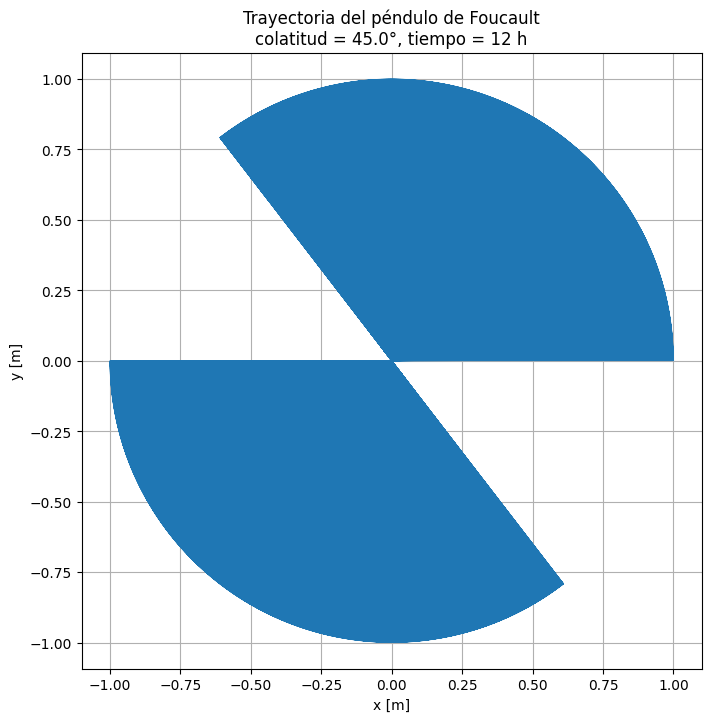

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Parámetros físicos
# -------------------------------------------------

g = 9.81          # gravedad, m/s^2
L = 10.0          # longitud del péndulo, m
A = 1.0           # amplitud horizontal, m

# Velocidad angular de la Tierra
Omega = 7.2921159e-5   # rad/s

# Colatitud theta
theta_deg = 45.0
theta = np.deg2rad(theta_deg)

# Frecuencia natural del péndulo
omega0 = np.sqrt(g / L)

# Frecuencia de precesión de Foucault
Omega_F = Omega * np.cos(theta)

print(f"Frecuencia natural del péndulo: {omega0:.6f} rad/s")
print(f"Frecuencia de Foucault: {Omega_F:.8e} rad/s")
print(f"Periodo de precesión: {2*np.pi/Omega_F/3600:.2f} horas")

# -------------------------------------------------
# Tiempo de simulación
# -------------------------------------------------

# Simulamos varias horas para que se vea la precesión.
horas = 12
t_final = horas * 3600

# Se necesitan muchos puntos porque el péndulo oscila rápido.
t = np.linspace(0, t_final, 200000)

# -------------------------------------------------
# Oscilación sin rotación
# -------------------------------------------------

q_x = A * np.cos(omega0 * t)
q_y = np.zeros_like(t)

# -------------------------------------------------
# Ángulo de precesión lenta
# -------------------------------------------------

alpha = Omega_F * t

# -------------------------------------------------
# Aplicación de la matriz de rotación efectiva
# -------------------------------------------------

x = np.cos(alpha) * q_x - np.sin(alpha) * q_y
y = np.sin(alpha) * q_x + np.cos(alpha) * q_y

# Como q_y = 0, esto equivale a:
#
# x = A*cos(omega0*t)*cos(Omega_F*t)
# y = A*cos(omega0*t)*sin(Omega_F*t)

# -------------------------------------------------
# Gráfica de la trayectoria
# -------------------------------------------------

plt.figure(figsize=(8, 8))
plt.plot(x, y, linewidth=0.5)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(
    f"Trayectoria del péndulo de Foucault\n"
    f"colatitud = {theta_deg:.1f}°, tiempo = {horas} h"
)

plt.axis("equal")
plt.grid(True)
plt.show()

In [2]:
x = np.zeros_like(t)
y = np.zeros_like(t)

for i, ti in enumerate(t):

    alpha_i = Omega * np.cos(theta) * ti

    R_ef = np.array([
        [np.cos(alpha_i), -np.sin(alpha_i)],
        [np.sin(alpha_i),  np.cos(alpha_i)]
    ])

    q = np.array([
        A * np.cos(omega0 * ti),
        0.0
    ])

    r = R_ef @ q

    x[i] = r[0]
    y[i] = r[1]

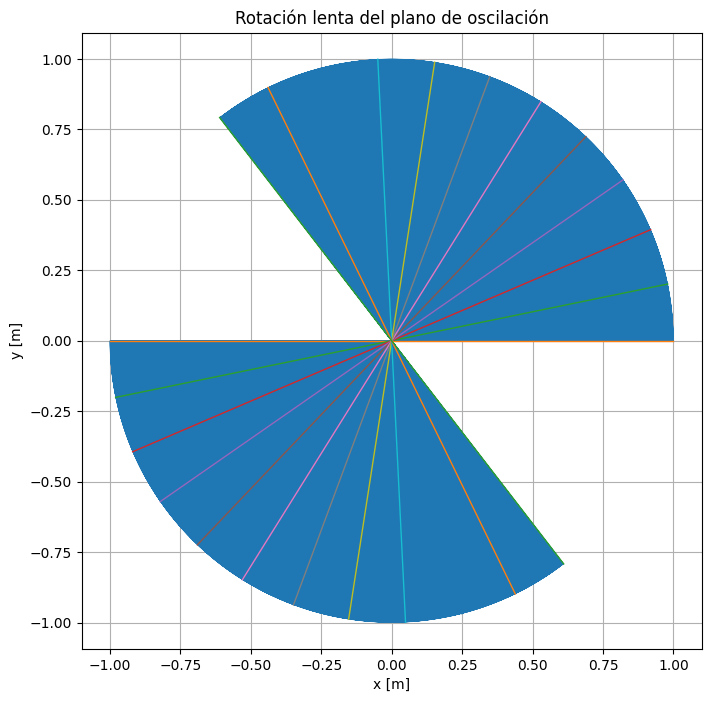

In [3]:
plt.figure(figsize=(8, 8))
plt.plot(x, y, linewidth=0.4)

# Dibujar algunas posiciones del plano de oscilación
for ti in np.linspace(0, t_final, 12):

    alpha_i = Omega_F * ti

    eje_x = A * np.cos(alpha_i)
    eje_y = A * np.sin(alpha_i)

    plt.plot(
        [-eje_x, eje_x],
        [-eje_y, eje_y],
        linewidth=1
    )

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Rotación lenta del plano de oscilación")
plt.axis("equal")
plt.grid(True)
plt.show()